# 1. Read File CSV Dataset Training

In [1]:
import pandas as pd 

dataset_training =  pd.read_csv('dataset/training/dataset_training.csv')
dataset_training

,Tweet,label
0,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu...",negative
1,"Sesama cewe lho (kayaknya), harusnya bisa lebi...",negative
2,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...,positive
3,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng...",negative
4,"Sharing pengalaman aja, kemarin jam 18.00 bata...",positive
...,...,...
915714,👻,negative
915715,😈😈😈😈😈😈😈😈,negative
915716,👍👍👍👍👍👍👍👍👍,negative
915717,😊😊,negative


In [2]:
# convert emoji to teks

import demoji

dataset_training['Tweet'] = dataset_training['Tweet'].apply(lambda x: demoji.replace_with_desc(x, sep=" "))
dataset_training


,Tweet,label
0,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu...",negative
1,"Sesama cewe lho (kayaknya), harusnya bisa lebi...",negative
2,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...,positive
3,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng...",negative
4,"Sharing pengalaman aja, kemarin jam 18.00 bata...",positive
...,...,...
915714,ghost,negative
915715,smiling face with horns smiling face with ho...,negative
915716,thumbs up thumbs up thumbs up thumbs up t...,negative
915717,smiling face with smiling eyes smiling face ...,negative


In [3]:
# count label

dataset_training['label'].value_counts()

label
positive    534024
negative    300745
neutral      80950
Name: count, dtype: int64

# 2. Exploration Data Analysis Dataset (EDA) Training

In [4]:
# split dataset_training to data_train and data_test (80:20)

from sklearn.model_selection import train_test_split

data_train, data_test = train_test_split(dataset_training, test_size=0.2, random_state=42)

In [5]:
# read data train

data_train

,Tweet,label
260080,"Maff ni sya kasih bintang 1, mengenai barang p...",negative
562740,Tidak melakukan apa-apa akun saya di blok tolo...,negative
114532,good,positive
358877,Saya suka menggunakan app ini.. Hanya di kota ...,positive
161400,Saya ingin. Mencoba bergabung dng blibli,positive
...,...,...
259178,"barang serba murah, banyak diskon , bnyak grat...",positive
365838,"Hallo ,,,, sdh 5 hari top up saya tidak di tin...",negative
131932,Bagus good thumbs up thumbs up thumbs up,neutral
671155,aplikasi ini bagus,positive


In [6]:
data_train.shape

(732575, 2)

In [7]:
data_test

,Tweet,label
156778,is the best,positive
550121,Mulai tidak ada kendala transfer/terima.semoga...,neutral
711372,sering sering kasih diskon gede2an biar tambah...,positive
193529,Paylater ny gak bisa d gunakan padahal gak per...,negative
353723,kenapa aplikasi gak bisa dibuka karena alasan ...,negative
...,...,...
330184,aplikasi gak guna. masa banyak promo akun saya...,negative
662845,Seru banget jadi lebih memahami,positive
358742,"Bagus,,cmn kok sring keluar sendiri ya Dan kal...",positive
397155,"Paling suka pakai aplikasi ini,tp tdk tau knp ...",positive


In [8]:
data_test.shape

(183144, 2)

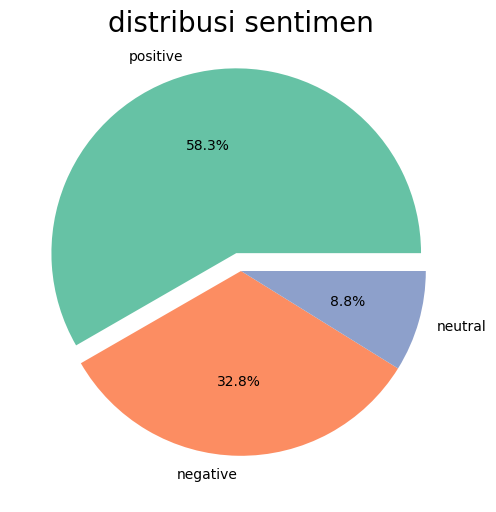

In [10]:
# look distribution label in dataset training use pie chart

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize = (6, 6))
sizes = [count for count in dataset_training['label'].value_counts()]
labels = list(data_train['label'].value_counts().index)
explode = (0.1, 0, 0)  # Offset the first segment

# Use color palet Seaborn
colors = sns.color_palette('Set2')
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, colors=colors, textprops={'fontsize': 10})
ax.set_title('distribusi sentimen', fontsize = 20)
plt.show()

Text(0.5, 1.0, 'Distribution of sentiment in training data')

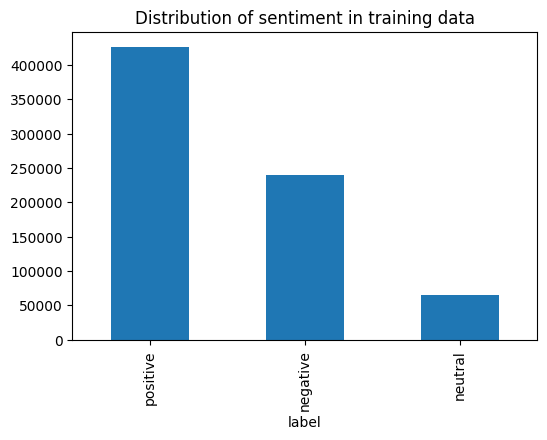

In [11]:
# look distribution label in data train use bar chart

plt.figure(figsize = (6,4))
data_train.label.value_counts().plot(kind = 'bar')
plt.title('Distribution of sentiment in training data')

Text(0.5, 1.0, 'Distribution of sentiment in testing data')

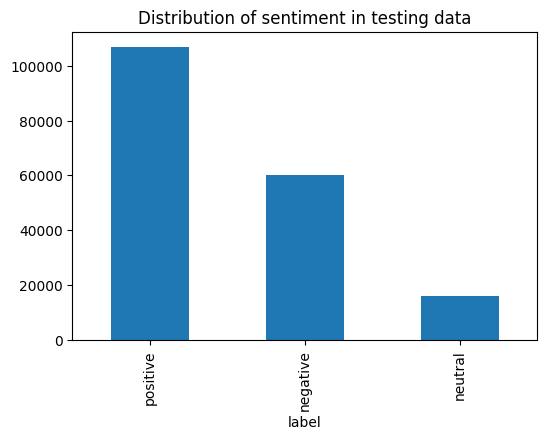

In [12]:
# look distribution label in data testing use bar chart

plt.figure(figsize = (6,4))
data_test.label.value_counts().plot(kind = 'bar')
plt.title('Distribution of sentiment in testing data')

## 2.1 Word Cloud

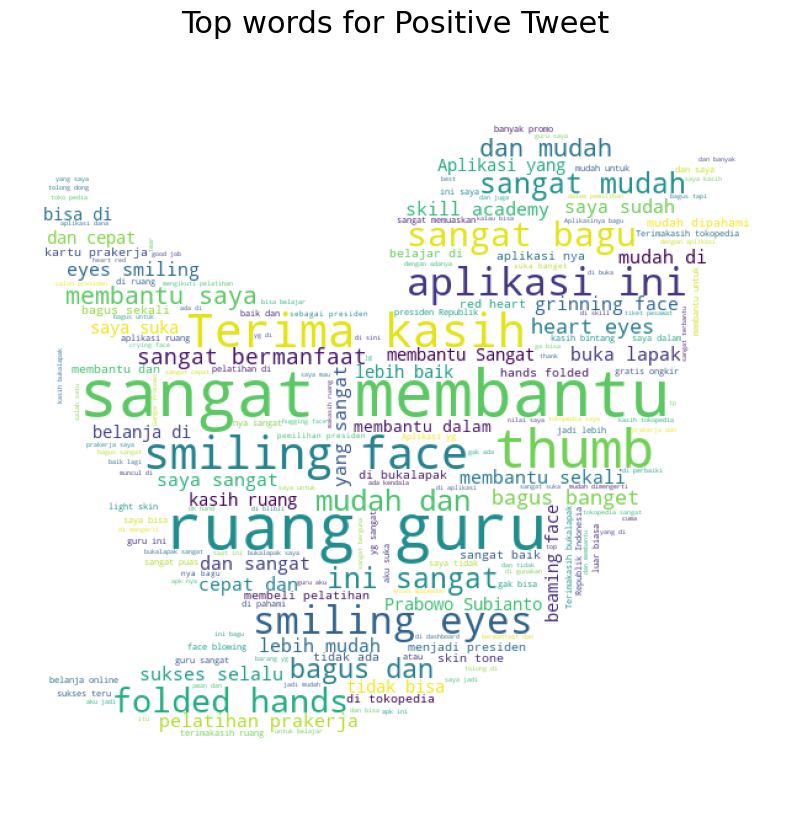

In [13]:
import requests
from PIL import Image
from io import BytesIO
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import numpy as np

url = "https://image.freepik.com/free-icon/twitter-logo_318-40459.jpg"  # replace with your image URL
response = requests.get(url)
twitter_mask = np.array(Image.open(BytesIO(response.content)))

wc = WordCloud(
    background_color='white',
    max_words=200,
    mask=twitter_mask,
)
wc.generate(' '.join(text for text in dataset_training.loc[dataset_training['label'] == 'positive', 'Tweet']))
plt.figure(figsize=(18,10))
plt.title('Top words for Positive Tweet',
          fontdict={'size': 22,  'verticalalignment': 'bottom'})
plt.imshow(wc)
plt.axis("off")
plt.show()

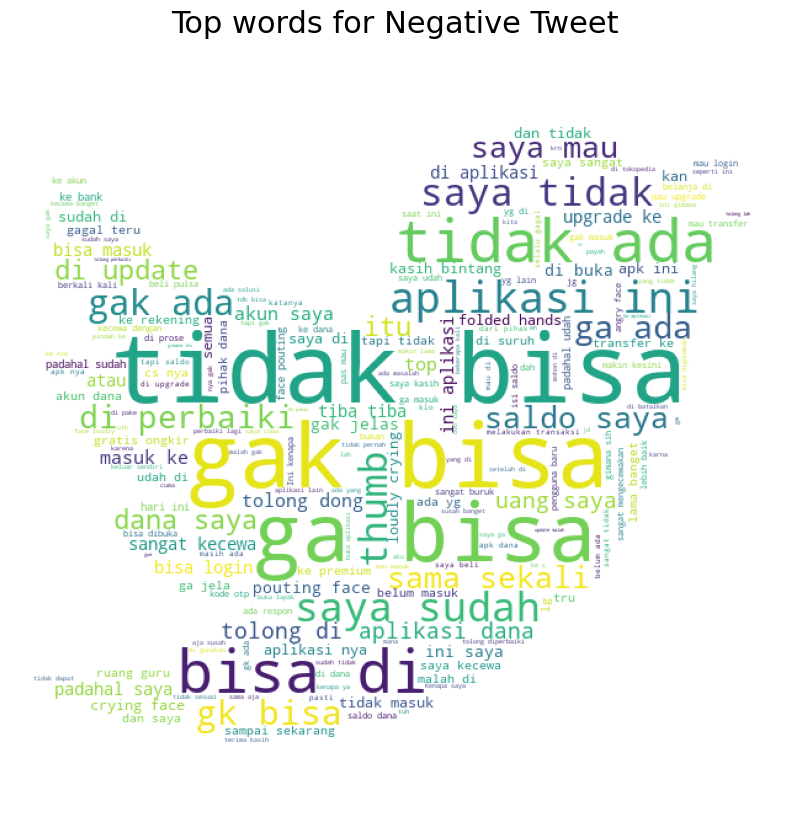

In [14]:
wc = WordCloud(
    background_color='white',
    max_words=200,
    mask=twitter_mask,
)
wc.generate(' '.join(text for text in dataset_training.loc[dataset_training['label'] == 'negative', 'Tweet']))
plt.figure(figsize=(18,10))
plt.title('Top words for Negative Tweet',
          fontdict={'size': 22,  'verticalalignment': 'bottom'})
plt.imshow(wc)
plt.axis("off")
plt.show()

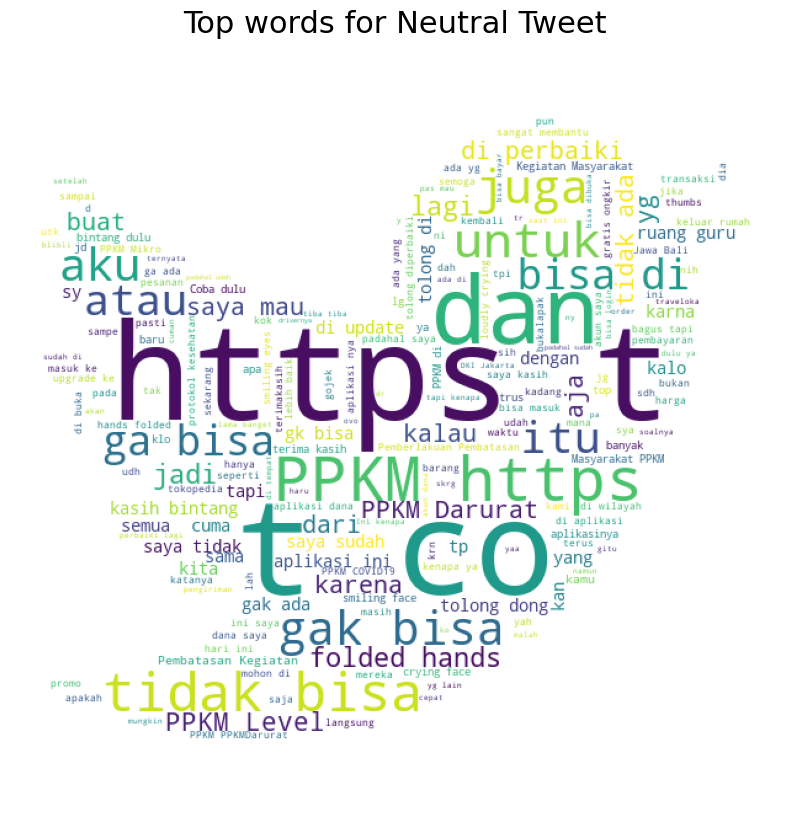

In [15]:
wc = WordCloud(
    background_color='white',
    max_words=200,
    mask=twitter_mask,
)
wc.generate(' '.join(text for text in dataset_training.loc[dataset_training['label'] == 'neutral', 'Tweet']))
plt.figure(figsize=(18,10))
plt.title('Top words for Neutral Tweet',
          fontdict={'size': 22,  'verticalalignment': 'bottom'})
plt.imshow(wc)
plt.axis("off")
plt.show()

In [16]:
# split coloumn in data_train and data_test

X_train = data_train['Tweet']
y_train = data_train['label']

X_test = data_test['Tweet']
y_test = data_test['label']

In [17]:
X_train

260080    Maff ni sya kasih bintang 1, mengenai barang p...
562740    Tidak melakukan apa-apa akun saya di blok tolo...
114532                                                 good
358877    Saya suka menggunakan app ini.. Hanya di kota ...
161400             Saya ingin. Mencoba bergabung dng blibli
                                ...                        
259178    barang serba murah, banyak diskon , bnyak grat...
365838    Hallo ,,,, sdh 5 hari top up saya tidak di tin...
131932         Bagus good  thumbs up  thumbs up  thumbs up 
671155                                   aplikasi ini bagus
121958                                  mantaaap thumbs up 
Name: Tweet, Length: 732575, dtype: str

In [18]:
y_train

260080    negative
562740    negative
114532    positive
358877    positive
161400    positive
            ...   
259178    positive
365838    negative
131932     neutral
671155    positive
121958    positive
Name: label, Length: 732575, dtype: str

In [19]:
X_test

156778                                          is the best
550121    Mulai tidak ada kendala transfer/terima.semoga...
711372    sering sering kasih diskon gede2an biar tambah...
193529    Paylater ny gak bisa d gunakan padahal gak per...
353723    kenapa aplikasi gak bisa dibuka karena alasan ...
                                ...                        
330184    aplikasi gak guna. masa banyak promo akun saya...
662845                      Seru banget jadi lebih memahami
358742    Bagus,,cmn kok sring keluar sendiri ya Dan kal...
397155    Paling suka pakai aplikasi ini,tp tdk tau knp ...
1851      waaah...rajin ya ay, pagi2 dah ke pasar... [US...
Name: Tweet, Length: 183144, dtype: str

In [20]:
y_test

156778    positive
550121     neutral
711372    positive
193529    negative
353723    negative
            ...   
330184    negative
662845    positive
358742    positive
397155    positive
1851      positive
Name: label, Length: 183144, dtype: str

# 3. Data Preprocessing

In [21]:
import openpyxl

# read file stopword_bahasa_indonesia

stopword_indonesia = pd.read_csv('dataset/text_normalization/stopword_bahasa_indonesia.csv')

# read file kamus gaul, typo, singkatan indonesia

dictionary_indonesia = pd.read_excel('dataset/text_normalization/kamus_singkatan_typo_gaul_indonesia.xlsx')

In [22]:
stopword_indonesia

,ada
0,adalah
1,adanya
2,adapun
3,agak
4,agaknya
...,...
752,wong
753,yaitu
754,yakin
755,yakni


In [23]:
dictionary_indonesia

,original,replacement
0,aaamiiinnn,amin
1,aamiiin,amin
2,aamiin,amin
3,aamiin,amin
4,abgmu,kakakmu
...,...,...
1208,yg,yang
1209,yha,ya
1210,yme,yang maha esa
1211,yutub,youtube


## 3.1 Cleaning

In [24]:
# import library

import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import nltk
from nltk.tokenize import word_tokenize

In [ ]:
class TextCleaner:

    # init
    def __init__(self, dictionary_df, stopword_df, remove_words=None):
        # Inisialisasi Sastrawi sekali saja agar cepat
        self.factory = StemmerFactory()
        self.stemmer = self.factory.create_stemmer()
        
        # Konversi Kamus Normalisasi ke Dictionary murni
        self.dictionary_map = dict(zip(dictionary_df['original'], dictionary_df['replacement']))
        
        # Konversi Stopword ke Set untuk pencarian cepat
        self.stop_set = set(stopword_indonesia.ada.values)
        
        # List kata spesifik yang ingin dihapus total
        self.remove_words = remove_words if remove_words else []
        
        # Kamus Kata Majemuk untuk digabung sebelum stemming
        self.compound_map = {
            r'\borang\s+tua\b': 'orangtua',
            r'\bterima\s+kasih\b': 'terimakasih',
            r'\btanggung\s+jawab\b': 'tanggungjawab',
            r'\bkerja\s+sama\b': 'kerjasama',
            r'\bsering\s+kali\b': 'seringkali',
            r'\bapa\s+pun\b': 'apapun',
            r'\bbagaimana\s+pun\b': 'bagaimanapun',
            r'\blog\s+in\b': 'login',
            r'\blog\s+out\b': 'logout',
            r'\bcash\s+back\b': 'cashback',
            r'\btik\s+tok\b': 'tiktok'
        }
    
    # function remove character
    def _remove_unnecessary_char(self, text):
        text = text.lower()
        
        # 1. TANGANI KATA ULANG ANGKA (jalan2 -> jalan jalan, ada2saja -> ada ada saja)
        # Mencari kata yang diikuti angka 2, lalu diulang kata tersebut
        text = re.sub(r'\b(\w+)2\b', r'\1 \1', text)
        
        # 2. HAPUS HASHTAG, USERNAME, URL
        text = re.sub(r'#\w+', ' ', text)
        text = re.sub(r'@[A-Za-z0-9_]+', ' ', text) 
        text = re.sub(r'((www\.[^\s]+)|(https?://[^\s]+))', ' ', text)
        
        # 3. NORMALISASI HURUF BERULANG (mbuuuhh -> mbuh)
        text = re.sub(r'(.)\1{2,}', r'\1', text)
        
        # 4. HAPUS SIMBOL (Ini otomatis menangani "(barang" -> "barang")
        # Menghapus semua yang bukan huruf dan angka, termasuk kurung dan kutip
        text = re.sub(r'[^0-9a-zA-Z]+', ' ', text)
        
        # 5. HAPUS KATA SPESIFIK (remove_words)
        for word in self.remove_words:
            text = re.sub(r'\b' + word + r'\b', ' ', text)
        return text

    # function fix compound words
    def _fix_compound_words(self, text):
        for pattern, replacement in self.compound_map.items():
            text = re.sub(pattern, replacement, text)
        return text

    # function normalize indonesian word
    def _normalize_indonesian(self, text):
        return ' '.join([self.dictionary_map.get(word, word) for word in text.split()])

    # function remove stopwords
    def _remove_stopwords(self, text):
        return ' '.join([word for word in text.split() if word not in self.stop_set])

    # funtion stemming
    def _stemming(self, text):
        # Tokenize dulu sebelum di-stem
        tokens = word_tokenize(text)
        return ' '.join([self.stemmer.stem(w) for w in tokens])

    # function full process
    def full_process(self, text):
        if not isinstance(text, str): return ""
        
        # Urutan: Karakter -> Normalisasi Alay -> Gabung Majemuk -> Stopword -> Stemming
        text = self._remove_unnecessary_char(text)
        text = self._normalize_indonesian(text)
        text = self._fix_compound_words(text)
        text = self._remove_stopwords(text)
        text = self._stemming(text)
        
        return re.sub(r'  +', ' ', text).strip()

In [ ]:

# list remove words
target_remove = [
    'username', 'ppkm', 'covid', 'covid19', 'corona', 'pandemi', 'pemerintah', 'jokowi', 
    'prabowo', 'subianto', 'ganjar', 'gangar', 'pranowo',
    'anies', 'baswedan', 'gibran', 'rakabuming', 'mahfud', 'muhaimin', 'iskandar', 'pilpres', 'pemilu', 
    'banjir', 'sumatra', 'presiden', 'gubernur', 'joko', 'widodo', 
    'gojek', 'traveloka', 'ovo', 'bukalapak', 'buka lapak', 'tokped', 'tokopedia', 'blibli', 'ruangguru', 'ruang guru' 'traveloka',
    'tiktok', 'instagram', 'facebook', 'twitter', 'x'
]

whitelist = ['@telkomsel', '@firstmedia', '@xlcare', ]

In [27]:

# initialize class
# Pastikan variabel dictionary_indonesia & stopword_indonesia sudah di-load sebelumnya
cleaner = TextCleaner(dictionary_indonesia, stopword_indonesia, remove_words=target_remove)

In [28]:
# run on dataframe
# Disarankan simpan ke kolom baru (misal: 'text_cleaned') agar data asli tetap ada
x_cleaning_train = X_train.apply(cleaner.full_process)
x_cleaning_train.head()

260080    maaf kasih bintang 1 barang pesan barang kemba...
562740    akun blokir tolong baik main blokir aja main b...
114532                                                bagus
358877    suka aplikasi kota tanjung pinang seringkali d...
161400                                          coba gabung
Name: Tweet, dtype: str

In [29]:
# make attribut for x_cleaning_train

data_train['text_cleaned'] = x_cleaning_train
data_train = data_train[['Tweet', 'text_cleaned', 'label']]
data_train

,Tweet,text_cleaned,label
260080,"Maff ni sya kasih bintang 1, mengenai barang p...",maaf kasih bintang 1 barang pesan barang kemba...,negative
562740,Tidak melakukan apa-apa akun saya di blok tolo...,akun blokir tolong baik main blokir aja main b...,negative
114532,good,bagus,positive
358877,Saya suka menggunakan app ini.. Hanya di kota ...,suka aplikasi kota tanjung pinang seringkali d...,positive
161400,Saya ingin. Mencoba bergabung dng blibli,coba gabung,positive
...,...,...,...
259178,"barang serba murah, banyak diskon , bnyak grat...",barang serba murah diskon gratis biaya kirim,positive
365838,"Hallo ,,,, sdh 5 hari top up saya tidak di tin...",hallo 5 top up tindak lanjut gimana ne tolong ...,negative
131932,Bagus good thumbs up thumbs up thumbs up,bagus bagus thumbs up thumbs up thumbs up,neutral
671155,aplikasi ini bagus,aplikasi bagus,positive


In [30]:
# save dataframe to csv

data_train.to_csv('data_train_clean.csv', index=False)

In [31]:
# run on dataframe
# Disarankan simpan ke kolom baru (misal: 'text_cleaned') agar data asli tetap ada
x_cleaning_test = X_test.apply(cleaner.full_process)
x_cleaning_test.head()

156778                                          is the best
550121         ada kendala transfer terima moga depan bagus
711372                    kasih diskon gede2an biar bintang
193529    paylater ny gak d gak telat seblm jatuh tempo ...
353723    aplikasi gak buka alas hp diroot aplikasi bodo...
Name: Tweet, dtype: str

In [32]:
# make attribut for x_cleaning_train

data_test['text_cleaned'] = x_cleaning_test
data_test = data_test[['Tweet', 'text_cleaned', 'label']]
data_test

,Tweet,text_cleaned,label
156778,is the best,is the best,positive
550121,Mulai tidak ada kendala transfer/terima.semoga...,ada kendala transfer terima moga depan bagus,neutral
711372,sering sering kasih diskon gede2an biar tambah...,kasih diskon gede2an biar bintang,positive
193529,Paylater ny gak bisa d gunakan padahal gak per...,paylater ny gak d gak telat seblm jatuh tempo ...,negative
353723,kenapa aplikasi gak bisa dibuka karena alasan ...,aplikasi gak buka alas hp diroot aplikasi bodo...,negative
...,...,...,...
330184,aplikasi gak guna. masa banyak promo akun saya...,aplikasi gak promo akun gak pakai 2 akun wlwpu...,negative
662845,Seru banget jadi lebih memahami,seru paham,positive
358742,"Bagus,,cmn kok sring keluar sendiri ya Dan kal...",bagus cuman ya ttansfer bunga rangin dikit min...,positive
397155,"Paling suka pakai aplikasi ini,tp tdk tau knp ...",suka pakai aplikasi tau knp pesan gofood susah...,positive


In [33]:
# save dataframe to csv

data_test.to_csv('data_test_clean.csv', index=False)

In [34]:
# merge data train & data test

dataset_training_clean = pd.concat([data_train, data_test], ignore_index=True)
dataset_training_clean

,Tweet,text_cleaned,label
0,"Maff ni sya kasih bintang 1, mengenai barang p...",maaf kasih bintang 1 barang pesan barang kemba...,negative
1,Tidak melakukan apa-apa akun saya di blok tolo...,akun blokir tolong baik main blokir aja main b...,negative
2,good,bagus,positive
3,Saya suka menggunakan app ini.. Hanya di kota ...,suka aplikasi kota tanjung pinang seringkali d...,positive
4,Saya ingin. Mencoba bergabung dng blibli,coba gabung,positive
...,...,...,...
915714,aplikasi gak guna. masa banyak promo akun saya...,aplikasi gak promo akun gak pakai 2 akun wlwpu...,negative
915715,Seru banget jadi lebih memahami,seru paham,positive
915716,"Bagus,,cmn kok sring keluar sendiri ya Dan kal...",bagus cuman ya ttansfer bunga rangin dikit min...,positive
915717,"Paling suka pakai aplikasi ini,tp tdk tau knp ...",suka pakai aplikasi tau knp pesan gofood susah...,positive


In [35]:
# save dataframe to csv

dataset_training_clean.to_csv('dataset_training_clean.csv', index=False)